# DeliveryOps Intelligence System — EDA

## Objective
Analyse delivery operations data to:
- Understand what drives delivery time
- Identify delay patterns (traffic, weather, distance)
- Prepare a clean dataset for modelling

## Target
- Regression: `delivery_time` (minutes)
- Classification (bonus): `delay_flag` (delayed vs not delayed)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data
Load the raw dataset from the `data/raw` folder.

In [2]:
df = pd.read_csv("../data/raw/amazon_delivery.csv")
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


## 2. Dataset Overview
Check columns, data types, and missing values.

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB


Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

## 3. Basic Cleaning
Drop rows with missing values (simple approach).

In [4]:
df = df.dropna().copy()
df.shape

(43594, 16)

In [5]:
df.columns = df.columns.str.strip().str.lower()
threshold = df["delivery_time"].mean()

## 4. Data Types
Convert categorical columns to category type (helps memory & clarity).

In [6]:
cat_cols = ["traffic_level", "weather", "vehicle_type"]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")
df.dtypes

order_id             object
agent_age             int64
agent_rating        float64
store_latitude      float64
store_longitude     float64
drop_latitude       float64
drop_longitude      float64
order_date           object
order_time           object
pickup_time          object
weather            category
traffic              object
vehicle              object
area                 object
delivery_time         int64
category             object
dtype: object

## 5. Create Delay Label (Classification Target)
We define "delay" as delivery time above a threshold.

A simple baseline threshold:
- Use the mean delivery time.
(You can later change this to 75th percentile to make it stricter.)

In [7]:
threshold = df["delivery_time"].mean()
df["delay_flag"] = (df["delivery_time"] > threshold).astype(int)

df[["delivery_time", "delay_flag"]].head()

,delivery_time,delay_flag
0,120,0
1,165,1
2,130,1
3,105,0
4,150,1


## 6. Delivery Time Distribution
We check how delivery times are distributed.

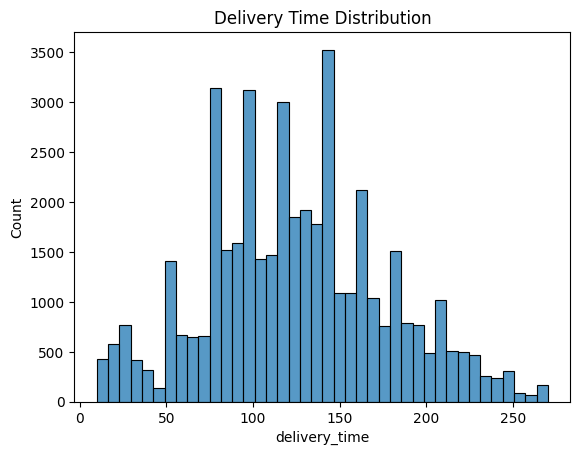

In [8]:
plt.figure()
sns.histplot(df["delivery_time"], bins=40)
plt.title("Delivery Time Distribution")
plt.show()

### Insight
Delivery time shows a spread with a longer tail, suggesting that some deliveries take much longer than average (likely driven by traffic/weather).

## Create Distance Feature (Haversine)

We compute the straight-line distance between store location and drop location using latitude/longitude.
This feature is important for predicting delivery time.

In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    R = 6371  # Earth radius in km
    return R * c

df["distance_km"] = haversine_km(
    df["store_latitude"], df["store_longitude"],
    df["drop_latitude"], df["drop_longitude"]
)

df[["store_latitude","store_longitude","drop_latitude","drop_longitude","distance_km"]].head()

,store_latitude,store_longitude,drop_latitude,drop_longitude,distance_km
0,22.745049,75.892471,22.765049,75.912471,3.025149
1,12.913041,77.683237,13.043041,77.813237,20.183530
2,12.914264,77.678400,12.924264,77.688400,1.552758
3,11.003669,76.976494,11.053669,77.026494,7.790401
4,12.972793,80.249982,13.012793,80.289982,6.210138


## 7. Distance vs Delivery Time
We expect delivery time to increase with distance, but traffic and weather will also contribute.

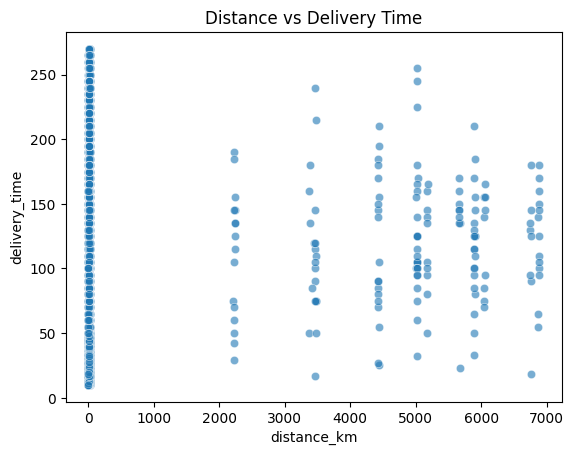

In [10]:
plt.figure()
sns.scatterplot(x="distance_km", y="delivery_time", data=df, alpha=0.6)
plt.title("Distance vs Delivery Time")
plt.show()

### Insight
Delivery time generally increases with distance, but variability suggests other operational factors like traffic and weather also play a strong role.

## Time Feature Engineering

We convert date and time columns into useful features:
- Hour of order
- Day of week
- Time difference between order and pickup

These features help capture operational patterns.

In [11]:
# Convert order_date
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

# Convert order_time & pickup_time
df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce")
df["pickup_time"] = pd.to_datetime(df["pickup_time"], format="%H:%M:%S", errors="coerce")

In [12]:
# Hour of order
df["order_hour"] = df["order_time"].dt.hour

# Day of week (0 = Monday)
df["day_of_week"] = df["order_date"].dt.dayofweek

# Weekend flag
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [13]:
# Time difference (minutes)
df["pickup_delay"] = (df["pickup_time"] - df["order_time"]).dt.total_seconds() / 60

In [14]:
df[["order_hour", "day_of_week", "pickup_delay"]].head()

,order_hour,day_of_week,pickup_delay
0,11,5,15.0
1,19,4,5.0
2,8,5,15.0
3,18,1,10.0
4,13,5,15.0


## Delivery Time by Hour

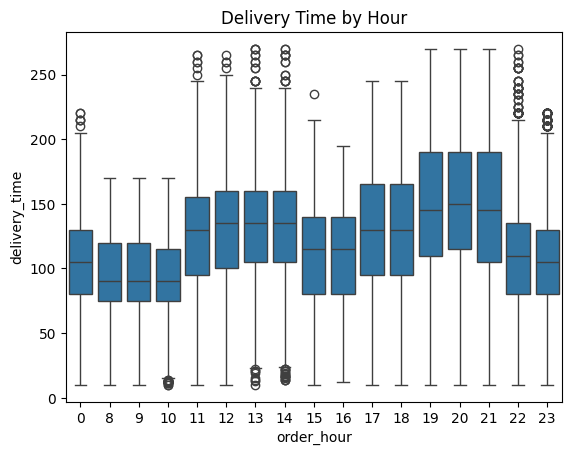

In [15]:
plt.figure()
sns.boxplot(x="order_hour", y="delivery_time", data=df)
plt.title("Delivery Time by Hour")
plt.show()

### Insight
Delivery time varies across the day, with certain hours showing higher delays, likely due to peak demand periods.

In [16]:
df["traffic"] = df["traffic"].astype("category")
df["vehicle"] = df["vehicle"].astype("category")
df["area"] = df["area"].astype("category")
df["category"] = df["category"].astype("category")

In [17]:
df.to_csv("../data/cleaned/cleaned_delivery.csv", index=False)
print("Saved cleaned dataset")

Saved cleaned dataset
